# Diagnóstico Jerárquico de Fallas del Molino Coloidal: Química Latinoamericana
### Comparación MLP vs SVC vs Random Forest vs LightGBM, con técnicas de regularización

**Dataset:** `Dataset_Molino_QLA_Realista.zip` (1 año de operación, 525.600 registros, 1 lectura por minuto)

# 1. Introducción

## 1.1 Proceso

La planta de emulsión asfáltica de Química Latinoamericana opera de la siguiente forma:

```
 Depósito de betún ─┐
                     ├─► Filtro ─► Válvula 3 vías ─► MOLINO COLOIDAL ─► (Intercambiador*) ─► Estanque de emulsión
 Depósito solución ─┘                  ▲                  100 hp, 2.900 RPM       * solo asfalto plastomérico, 2–3 bar
                                        └── agua limpia + aire (limpieza de línea, 260 L/min)
```

| Variable | Convencional | Plastomérico |
|---|---|---|
| Betún | 130–145 °C | 180–200 °C |
| Solución | 35 °C | 45 °C |
| Emulsión | 75 °C | 80 °C |
| Intercambiador | no se usa | 2–3 bar |

La planta trabaja de lunes a viernes de 08:00 a 17:00 y produce cerca de 25 toneladas diarias en lotes a 181 L/min. Al final del día se limpia la línea. Fuera de turno está detenida y las calderas mantienen la temperatura. Se hace mantenimiento todos los meses.

## 1.2 Problemática

Cuando el molino está en marcha, el operador necesita responder dos preguntas:

1. **¿El molino está operando normal?** Si la respuesta es sí, se continúa monitoreando.
2. **Si no, ¿qué está fallando?** Hay siete fallas posibles, y cada una requiere un técnico o una acción distinta.

Resolver ambas preguntas con un único clasificador de 8 clases obliga al modelo a aprender al mismo tiempo la frontera "normal vs anómalo" y las fronteras finas entre fallas, con una clase Normal que representa cerca del 88 % de los minutos. En la práctica esto genera **falsas alarmas**.

## 1.3 Arquitectura jerárquica propuesta

```
                 Lectura de sensores del molino en marcha
                                   │
                                   ▼
               ┌───────────────────────────────────────┐
               │  MODELO 1 · DETECCIÓN GENERAL          │
               │  ¿Estado General == "Normal"?          │
               └───────────────────────────────────────┘
                     │ Sí                            │ No
                     ▼                               ▼
         [OK: Continuar Monitoreo]     ┌──────────────────────────────┐
                                       │ MODELO 2 · DIAGNÓSTICO /      │
                                       │ AISLAMIENTO (7 tipos de falla)│
                                       └──────────────────────────────┘
```

**Fallas que diagnostica el Modelo 2:**

| Falla | Equipo | Firma en los sensores |
|---|---|---|
| Sobrecarga del motor por asfalto frío | Molino / caldera | Betún frío, sube corriente, torque y vibración |
| Radar sucio | Estanque de betún | Eco del radar débil, estado NAMUR en falla |
| Filtro obstruido | Filtro de línea | Sube la presión diferencial y cae el caudal |
| Cortocircuito del transmisor de caudal | Caudalímetro de solución | Lazo 4–20 mA saturado sobre 22 mA |
| Falla eléctrica de la Pt100 | Sonda de betún | Temperatura, resistencia y alimentación en 0 |
| Ensuciamiento del intercambiador | Intercambiador | Sube la presión y la temperatura de salida |
| Desgaste de rodamientos | Molino | Vibración alta sin betún frío |

## 1.4 Objetivo

Identificar la falla cuando el molino está en marcha, comparando en cada etapa cuatro familias de modelos, cada una con sus propias técnicas de regularización:

| Familia | Implementación | Regularización que se compara |
|---|---|---|
| **MLP** | TensorFlow / Keras | L1, L2, Dropout, BatchNormalization, EarlyStopping, ReduceLROnPlateau |
| **SVC** (kernel RBF) | `sklearn.svm.SVC` | `C` (margen suave) y `gamma` (suavidad de la frontera) |
| **Random Forest** | `sklearn.ensemble.RandomForestClassifier` | Profundidad máxima, mínimo de muestras por hoja, submuestreo de variables y de filas (bagging) |
| **LightGBM** | `lightgbm.LGBMClassifier` | Número de hojas, mínimo de muestras por hoja, L1 y L2 sobre las hojas, submuestreo y early stopping |

El procedimiento es el mismo para todas:

1. **Seleccionar** hiperparámetros con un conjunto de **validación cronológico**.
2. **Reentrenar** la mejor configuración con todo el histórico.
3. **Evaluar** en el periodo de prueba, que ningún modelo vio.

Al final se descarga el **mejor sistema**, elegido por su desempeño en validación.

# 2. Carga y preprocesamiento de datos

## 2.1 Importación de librerías

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2

import zipfile
from itertools import product
import lightgbm as lgb
from lightgbm import LGBMClassifier

import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
print("TensorFlow:", tf.__version__, "| scikit-learn:", sklearn.__version__, "| LightGBM:", lgb.__version__)

I0000 00:00:1790887113.432464     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790887113.631673     874 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790887115.490544     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | scikit-learn: 1.8.0 | LightGBM: 4.7.0


## 2.2 Carga del dataset

Pandas lee el `.zip` directamente. Si el archivo no está en el panel de Colab, la celda muestra el botón **"Elegir archivos"**.

In [2]:
RUTA = "Dataset_Molino_QLA_Realista.zip"

if not os.path.exists(RUTA):
    try:
        from google.colab import files
        print("Selecciona Dataset_Molino_QLA_Realista.zip (o el .csv)")
        subido = files.upload()
        RUTA = list(subido.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"No se encontró {RUTA} en el directorio actual.")

df_completo = pd.read_csv(RUTA, parse_dates=["timestamp"])
TARGET = "LABEL_Estado_Planta"
print(f"Dimensiones: {df_completo.shape[0]:,} filas x {df_completo.shape[1]} columnas".replace(",", "."))
print("Valores nulos:", df_completo.isna().sum().sum())
df_completo.head()

Dimensiones: 525.600 filas x 45 columnas
Valores nulos: 0


,timestamp,TEM_son_betum_in,RES_son_betum_in,VOLT_son_betum_in,AMP_son_betum_in,AMP_cau_betum_in,FRE_cau_betum_in,VOLT_cau_betum_in,AMP_niv_betum_dep,VOLT_niv_betum_dep,DIS_niv_betum_dep,POR_niv_betum_dep,VOL_niv_betum_dep,AMP_eco_betum_dep,EST_niv_betum_dep,TEM_son_solucion_in,RES_son_solucion_in,AMP_son_solucion_in,AMP_cau_solucion_in,FRE_cau_solucion_in,DIS_niv_solucion_dep,POR_niv_solucion_dep,AMP_eco_solucion_dep,TEM_son_emulsion_out,RES_son_emulsion_out,AMP_cau_emulsion_out,FRE_cau_emulsion_out,AMP_niv_emulsion_dep,DIS_niv_emulsion_dep,AMP_eco_emulsion_dep,RPM_motor_molino,FRE_vfd_motor_molino,AMP_vfd_motor_molino,TOR_vfd_motor_molino,VIB_vel_motor_molino,AMP_vib_motor_molino,ESTADO_operacion,TIPO_asfalto,CAU_bomba_lpm,PRE_dif_filtro_bar,POS_valvula_3vias,VAL_aire_linea,TEM_emulsion_molino_out,PRE_intercambiador_bar,LABEL_Estado_Planta
0,2026-01-01 00:00:00,190.00,173.150,24.0,16.160,4.000,250.00,24.0,15.200,24.0,4.500,70.00,21000.00,62.041,0.0,25.00,109.625,8.000,4.000,400.00,6.0,60.0,70.000,59.99,123.097,4.000,320.00,10.4,9.0,60.000,0.0,0.0,0.0,0.0,0.10,4.063,Detenida,Ninguno,0.0,0.000,0,0,40.000,0.0,Normal
1,2026-01-01 00:01:00,190.18,173.219,24.0,16.171,4.004,250.18,24.0,15.178,24.0,4.521,69.86,20957.90,61.980,0.0,24.71,109.515,7.954,4.006,399.52,6.0,60.0,69.672,59.82,123.030,3.995,320.54,10.4,9.0,59.815,0.0,0.0,0.0,0.0,0.10,4.062,Detenida,Ninguno,0.0,0.013,0,0,39.795,0.0,Normal
2,2026-01-01 00:02:00,190.31,173.271,24.0,16.180,4.001,250.29,24.0,15.202,24.0,4.498,70.01,21003.19,62.808,0.0,24.76,109.533,7.962,3.999,399.73,6.0,60.0,70.107,59.89,123.059,3.993,321.11,10.4,9.0,60.121,0.0,0.0,0.0,0.0,0.11,4.069,Detenida,Ninguno,0.0,0.001,0,0,39.778,0.0,Normal
3,2026-01-01 00:03:00,190.32,173.272,24.0,16.180,4.004,249.94,24.0,15.211,24.0,4.490,70.07,21020.15,62.910,0.0,24.68,109.502,7.949,3.999,399.86,6.0,60.0,70.221,59.82,123.032,3.997,320.99,10.4,9.0,61.352,0.0,0.0,0.0,0.0,0.09,4.058,Detenida,Ninguno,0.0,0.005,0,0,39.557,0.0,Normal
4,2026-01-01 00:04:00,189.98,173.142,24.0,16.159,4.000,250.03,24.0,15.210,24.0,4.491,70.06,21017.85,63.862,0.0,24.74,109.524,7.958,4.005,399.68,6.0,60.0,69.391,59.93,123.072,4.001,320.88,10.4,9.0,61.628,0.0,0.0,0.0,0.0,0.13,4.080,Detenida,Ninguno,0.0,0.002,0,0,39.574,0.0,Normal


## 2.3 Exploración: operación de la planta

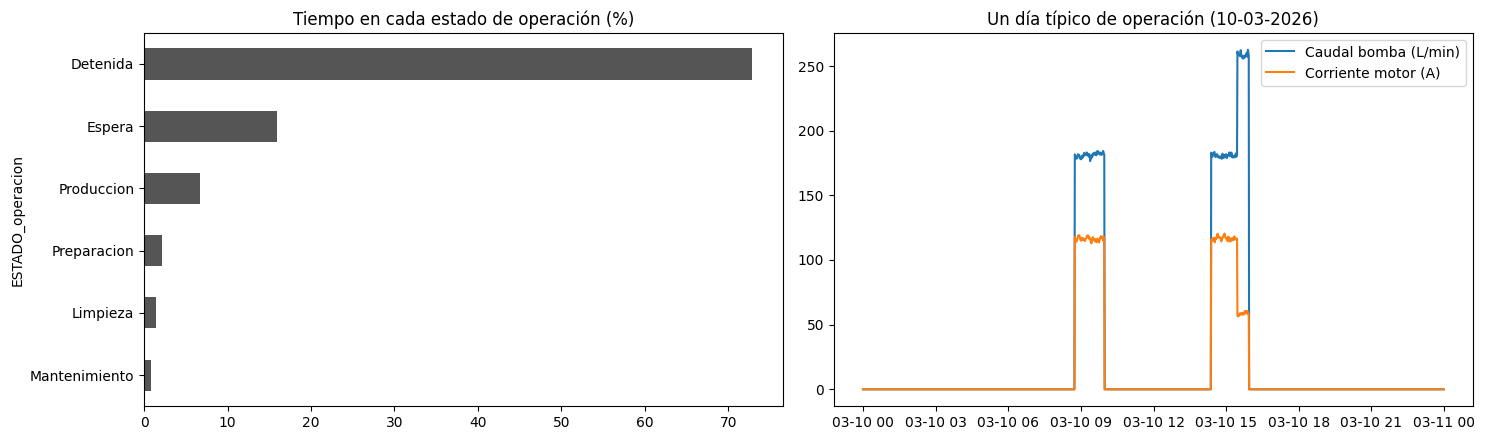

TIPO_asfalto,Convencional,Ninguno,Plastomerico
ESTADO_operacion,,,
Detenida,179100,152640,51300
Espera,65236,0,18754
Limpieza,5866,0,1692
Mantenimiento,0,4320,0
Preparacion,8955,0,2565
Produccion,27403,0,7769


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
estados = df_completo["ESTADO_operacion"].value_counts()
(estados / len(df_completo) * 100).plot(kind="barh", ax=ax[0], color="#555")
ax[0].set_title("Tiempo en cada estado de operación (%)"); ax[0].invert_yaxis()

un_dia = df_completo[df_completo["timestamp"].dt.date == pd.Timestamp("2026-03-10").date()]
ax[1].plot(un_dia["timestamp"], un_dia["CAU_bomba_lpm"], label="Caudal bomba (L/min)")
ax[1].plot(un_dia["timestamp"], un_dia["AMP_vfd_motor_molino"], label="Corriente motor (A)")
ax[1].set_title("Un día típico de operación (10-03-2026)"); ax[1].legend()
plt.tight_layout(); plt.show()

pd.crosstab(df_completo["ESTADO_operacion"], df_completo["TIPO_asfalto"])

La planta pasa cerca del 73 % del tiempo **detenida** (noches, fines de semana y feriados) y el molino solo gira durante la **producción** y la **limpieza de línea**, unas 2,8 horas al día. En el gráfico del día típico se ven los dos lotes de producción a 181 L/min y la limpieza final a 260 L/min.

## 2.4 Alcance del modelo: molino en marcha

El modelo se entrena y se aplica **solo cuando el molino está en marcha** (estados `Produccion` y `Limpieza`):

* Un motor detenido tiene corriente, torque y vibración en cero. Eso **no es una falla**, pero un modelo entrenado con todos los minutos tendría que aprender siete "normalidades" distintas.
* Las fallas mecánicas y de proceso (sobrecarga, filtro, intercambiador, rodamientos) **solo se manifiestan con el molino girando**.
* Las fallas de instrumentos con la planta detenida (por ejemplo, una Pt100 que falla de noche) se cubren con alarmas por límite en el dashboard.

In [4]:
en_marcha = df_completo["ESTADO_operacion"].isin(["Produccion", "Limpieza"])
df = df_completo[en_marcha].reset_index(drop=True)
print(f"Minutos con el molino en marcha: {len(df):,} de {len(df_completo):,}".replace(",", "."))

conteo = df[TARGET].value_counts()
pd.DataFrame({"minutos": conteo, "porcentaje (%)": (conteo / len(df) * 100).round(2)})

Minutos con el molino en marcha: 42.730 de 525.600


,minutos,porcentaje (%)
LABEL_Estado_Planta,,
Normal,37676,88.17
Sobrecarga_Motor_Por_Asfalto_Frio,3419,8.00
Advertencia_Radar_Sucio_Betun,579,1.36
Filtro_Obstruido,327,0.77
Cortocircuito_Transmisor_Caudal_Sol,280,0.66
Falla_Electrica_PT100_Betun,263,0.62
Ensuciamiento_Intercambiador,133,0.31
Desgaste_Rodamientos_Molino,53,0.12


### Episodios de falla en el año

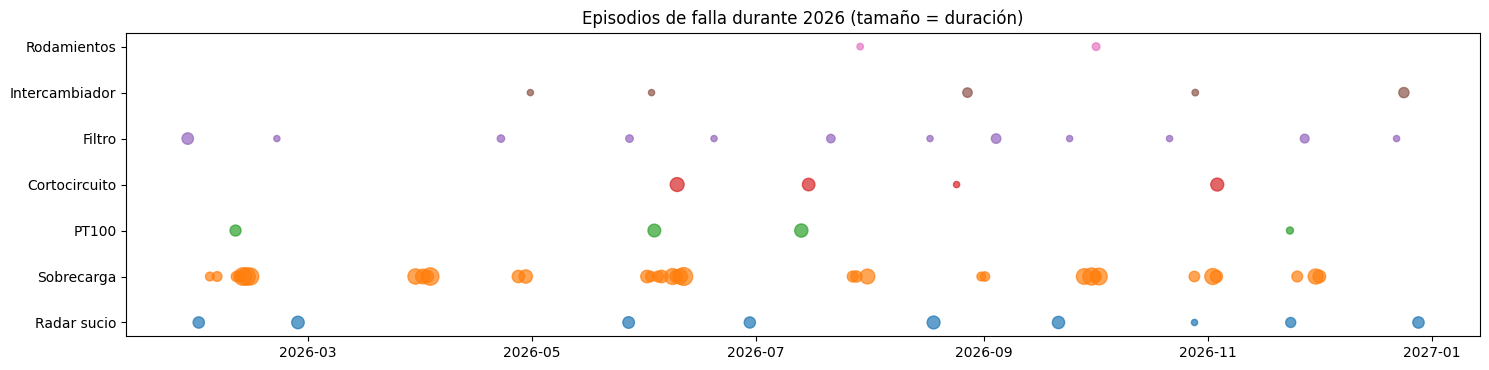

,n_episodios,duracion_media
estado,,
Advertencia_Radar_Sucio_Betun,9,64.0
Cortocircuito_Transmisor_Caudal_Sol,4,70.0
Desgaste_Rodamientos_Molino,2,26.0
Ensuciamiento_Intercambiador,5,27.0
Falla_Electrica_PT100_Betun,4,66.0
Filtro_Obstruido,12,27.0
Sobrecarga_Motor_Por_Asfalto_Frio,36,95.0


In [5]:
bloque = (df[TARGET] != df[TARGET].shift()).cumsum()
episodios = df.groupby(bloque).agg(estado=(TARGET, "first"), minutos=(TARGET, "size"), inicio=("timestamp", "first"))
episodios = episodios[episodios["estado"] != "Normal"]

etiquetas_cortas = {
    "Normal": "Normal",
    "Advertencia_Radar_Sucio_Betun": "Radar sucio",
    "Sobrecarga_Motor_Por_Asfalto_Frio": "Sobrecarga",
    "Falla_Electrica_PT100_Betun": "PT100",
    "Cortocircuito_Transmisor_Caudal_Sol": "Cortocircuito",
    "Filtro_Obstruido": "Filtro",
    "Ensuciamiento_Intercambiador": "Intercambiador",
    "Desgaste_Rodamientos_Molino": "Rodamientos",
}
orden_y = list(etiquetas_cortas)[1:]
fig, ax = plt.subplots(figsize=(15, 3.8))
for i, e in enumerate(orden_y):
    ep = episodios[episodios["estado"] == e]
    ax.scatter(ep["inicio"], [i] * len(ep), s=np.clip(ep["minutos"], 20, 300), alpha=0.7)
ax.set_yticks(range(len(orden_y))); ax.set_yticklabels([etiquetas_cortas[e] for e in orden_y])
ax.set_title("Episodios de falla durante 2026 (tamaño = duración)")
plt.tight_layout(); plt.show()

episodios.groupby("estado")["minutos"].agg(n_episodios="count", duracion_media="mean").round(0)

Hay fallas frecuentes (sobrecarga, filtro, radar) y otras muy raras (rodamientos, intercambiador), como en una planta real. Las **sobrecargas se concentran en invierno** (junio a agosto), cuando el betún pierde más temperatura.

### Firma de cada falla en los sensores

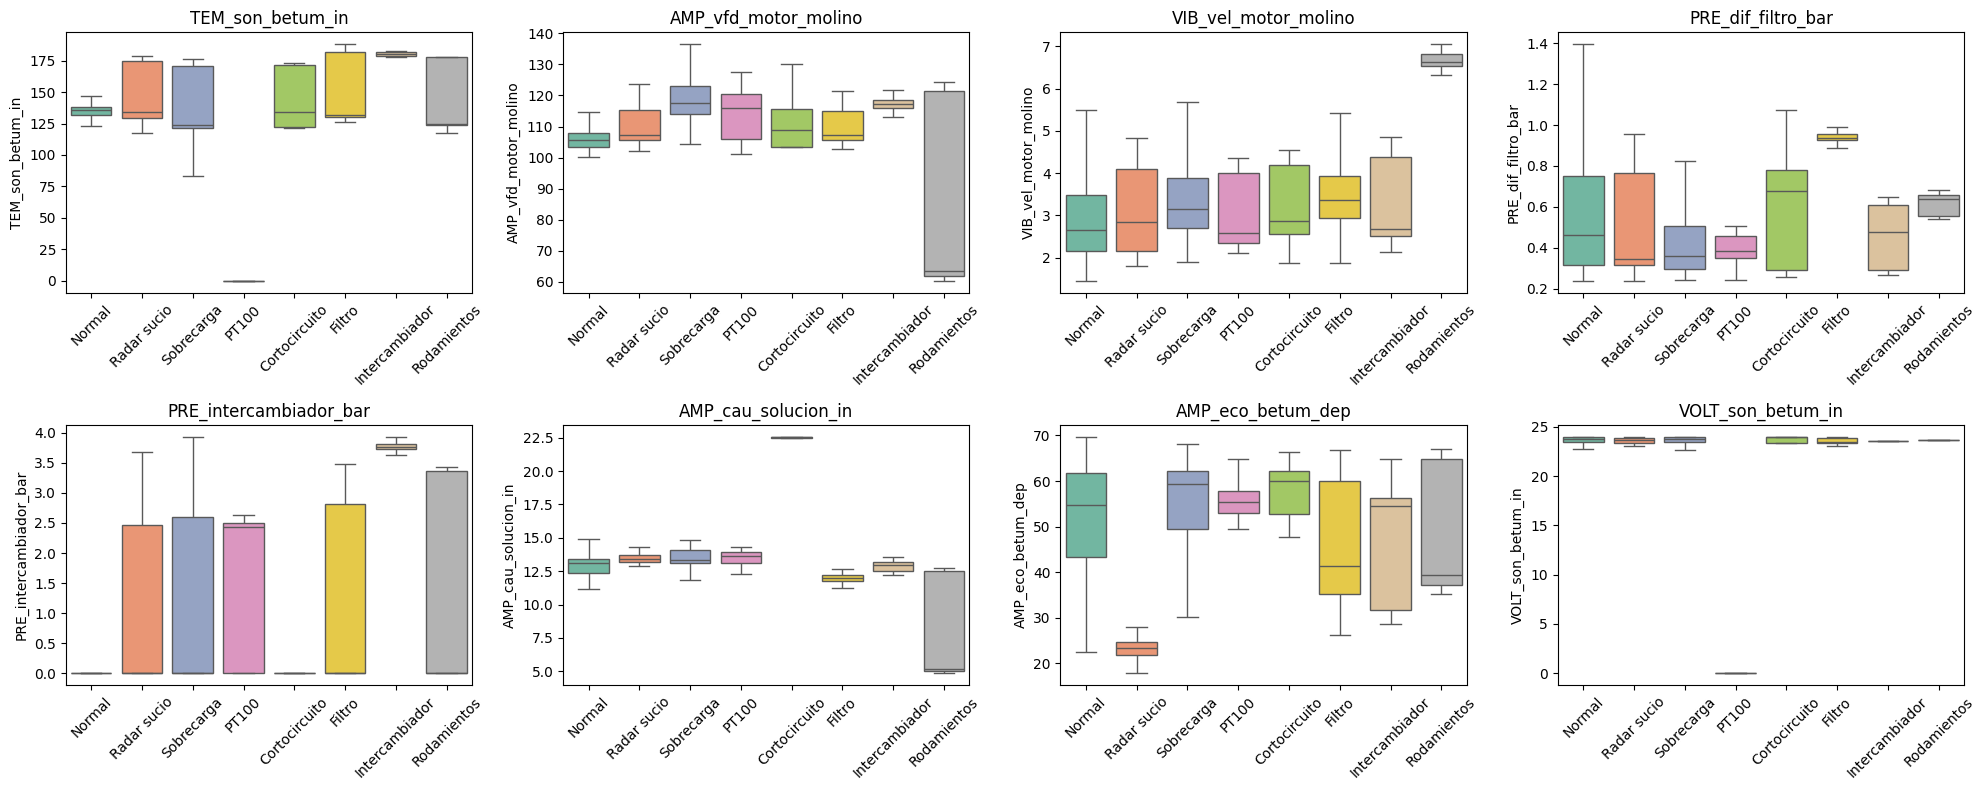

In [6]:
senales = ["TEM_son_betum_in", "AMP_vfd_motor_molino", "VIB_vel_motor_molino", "PRE_dif_filtro_bar",
           "PRE_intercambiador_bar", "AMP_cau_solucion_in", "AMP_eco_betum_dep", "VOLT_son_betum_in"]
tmp = df.assign(clase=df[TARGET].map(etiquetas_cortas))
orden_x = list(etiquetas_cortas.values())
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, s in zip(axes.ravel(), senales):
    sns.boxplot(data=tmp, x="clase", y=s, order=orden_x, ax=ax, showfliers=False, palette="Set2")
    ax.set_title(s); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

Cada falla deja una huella física propia:

* **Sobrecarga:** betún bajo 125 °C (convencional) o 175 °C (plastomérico); la corriente sube sobre 115 A y el torque y la vibración aumentan.
* **Filtro obstruido:** la presión diferencial supera ~1 bar y el caudal de la bomba cae.
* **Intercambiador:** la presión sube de 2–3 bar a más de 3,5 bar y la emulsión sale más caliente.
* **Rodamientos:** vibración sobre 4,5 mm/s sin que el betún esté frío.
* **Pt100, cortocircuito y radar:** fallas de instrumento con valores característicos (0 V, 22,5 mA, eco bajo 25 dB).

## 2.5 Selección de variables

* Se eliminan `timestamp`, `ESTADO_operacion`, `TIPO_asfalto` y la etiqueta.
* Se eliminan las columnas **constantes**.
* Se eliminan las **variables de nivel de estanque** (porcentaje, volumen, distancia y corriente de nivel). Describen cuán lleno está un estanque, no la salud de un equipo; en el dataset anterior se demostró que generan atajos que no se repiten en el futuro.
* `POS_valvula_3vias` y `VAL_aire_linea` son idénticas durante el molino en marcha (ambas indican limpieza), así que se reemplazan por una sola variable de contexto.

Se agregan dos **variables de contexto** binarias, porque los valores normales dependen de ellas:

* `es_plastomerico`: el betún normal está a 190 °C en vez de 138 °C, y se usa el intercambiador.
* `en_limpieza`: por la línea pasa agua con aire a 260 L/min, con el motor a media carga.

In [7]:
df["es_plastomerico"] = (df["TIPO_asfalto"] == "Plastomerico").astype(int)
df["en_limpieza"] = (df["ESTADO_operacion"] == "Limpieza").astype(int)

excluir = {"timestamp", TARGET, "ESTADO_operacion", "TIPO_asfalto", "POS_valvula_3vias", "VAL_aire_linea"}
candidatas = [c for c in df.columns if c not in excluir]
constantes = [c for c in candidatas if df[c].nunique() == 1]
VARIABLES_NIVEL = [c for c in candidatas if any(k in c for k in ["POR_niv", "VOL_niv", "DIS_niv", "AMP_niv"])]
FEATURES = [c for c in candidatas if c not in constantes + VARIABLES_NIVEL]
CONTEXTO = ["es_plastomerico", "en_limpieza"]

print("Constantes eliminadas     :", constantes)
print("Variables de nivel quitadas:", VARIABLES_NIVEL)
print(f"Variables de entrada ({len(FEATURES)}):", FEATURES)

Constantes eliminadas     : ['VOLT_cau_betum_in', 'VOLT_niv_betum_dep']
Variables de nivel quitadas: ['AMP_niv_betum_dep', 'DIS_niv_betum_dep', 'POR_niv_betum_dep', 'VOL_niv_betum_dep', 'DIS_niv_solucion_dep', 'POR_niv_solucion_dep', 'AMP_niv_emulsion_dep', 'DIS_niv_emulsion_dep']
Variables de entrada (31): ['TEM_son_betum_in', 'RES_son_betum_in', 'VOLT_son_betum_in', 'AMP_son_betum_in', 'AMP_cau_betum_in', 'FRE_cau_betum_in', 'AMP_eco_betum_dep', 'EST_niv_betum_dep', 'TEM_son_solucion_in', 'RES_son_solucion_in', 'AMP_son_solucion_in', 'AMP_cau_solucion_in', 'FRE_cau_solucion_in', 'AMP_eco_solucion_dep', 'TEM_son_emulsion_out', 'RES_son_emulsion_out', 'AMP_cau_emulsion_out', 'FRE_cau_emulsion_out', 'AMP_eco_emulsion_dep', 'RPM_motor_molino', 'FRE_vfd_motor_molino', 'AMP_vfd_motor_molino', 'TOR_vfd_motor_molino', 'VIB_vel_motor_molino', 'AMP_vib_motor_molino', 'CAU_bomba_lpm', 'PRE_dif_filtro_bar', 'TEM_emulsion_molino_out', 'PRE_intercambiador_bar', 'es_plastomerico', 'en_limpieza']


## 2.6 Construcción de las etiquetas jerárquicas

* **`y_etapa1`** → 0 = Normal, 1 = Anomalía. Etiqueta del Modelo 1.
* **`y_etapa2`** → tipo de falla, codificado 0–6. Solo para registros anómalos. Etiqueta del Modelo 2.

In [8]:
df["y_etapa1"] = (df[TARGET] != "Normal").astype(int)
CLASES_FALLA = sorted(df.loc[df[TARGET] != "Normal", TARGET].unique())
le_falla = LabelEncoder().fit(CLASES_FALLA)

print("Etapa 1 ->", df["y_etapa1"].value_counts().rename({0: "Normal", 1: "Anomalía"}).to_dict())
print("\nEtapa 2 (codificación de fallas):")
for i, c in enumerate(le_falla.classes_):
    print(f"  {i} -> {c}")

Etapa 1 -> {'Normal': 37676, 'Anomalía': 5054}

Etapa 2 (codificación de fallas):
  0 -> Advertencia_Radar_Sucio_Betun
  1 -> Cortocircuito_Transmisor_Caudal_Sol
  2 -> Desgaste_Rodamientos_Molino
  3 -> Ensuciamiento_Intercambiador
  4 -> Falla_Electrica_PT100_Betun
  5 -> Filtro_Obstruido
  6 -> Sobrecarga_Motor_Por_Asfalto_Frio


## 2.7 División en entrenamiento, validación y prueba

Todo se divide **en orden cronológico**, porque minutos consecutivos de un mismo episodio son casi idénticos y una división al azar sobrestima el desempeño. En la versión anterior del notebook la validación al azar daba F1 = 1,0 a todos los modelos y no servía para elegir.

| Conjunto | Periodo | Uso |
|---|---|---|
| **Entrenamiento** | 1 de enero a mediados de junio | Ajustar cada configuración |
| **Validación** | Mediados de junio al 7 de agosto | Elegir hiperparámetros y el mejor sistema |
| **Histórico** (entrenamiento + validación) | Enero al 7 de agosto | Reentrenar la configuración elegida |
| **Prueba** | 7 de agosto a fin de año | Evaluación final, nunca vista |

**Submuestreo de la clase Normal.** En el entrenamiento se conservan todas las fallas y 6.000 minutos normales elegidos al azar. Así el SVC puede entrenarse en un tiempo razonable, y las cuatro familias reciben exactamente los mismos datos. Validación y prueba mantienen la proporción real, para que la tasa de falsas alarmas medida sea realista.

In [9]:
corte = int(len(df) * 0.60)
df_historico, df_test = df.iloc[:corte].copy(), df.iloc[corte:].copy()
corte_val = int(len(df_historico) * 0.75)
df_train_completo, df_val = df_historico.iloc[:corte_val].copy(), df_historico.iloc[corte_val:].copy()

N_NORMALES = 6000
normales = df_train_completo[df_train_completo[TARGET] == "Normal"].sample(N_NORMALES, random_state=SEED)
df_train = pd.concat([normales, df_train_completo[df_train_completo[TARGET] != "Normal"]]).sample(frac=1, random_state=SEED)
df_hist = pd.concat([df_train, df_val])          # para el reentrenamiento final

resumen = pd.DataFrame({"train": df_train[TARGET].value_counts(), "val": df_val[TARGET].value_counts(),
                        "test": df_test[TARGET].value_counts()}).fillna(0).astype(int)
resumen.loc["TOTAL"] = resumen.sum()
for nombre, d in [("Entrenamiento", df_train_completo), ("Validación", df_val), ("Prueba", df_test)]:
    print(f"{nombre:<14} {d['timestamp'].min():%d-%m-%Y} a {d['timestamp'].max():%d-%m-%Y}")
resumen

Entrenamiento  02-01-2026 a 12-06-2026
Validación     12-06-2026 a 06-08-2026
Prueba         07-08-2026 a 31-12-2026


,train,val,test
LABEL_Estado_Planta,,,
Advertencia_Radar_Sucio_Betun,217,65,297
Cortocircuito_Transmisor_Caudal_Sol,100,81,99
Desgaste_Rodamientos_Molino,0,22,31
Ensuciamiento_Intercambiador,11,0,122
Falla_Electrica_PT100_Betun,147,90,26
Filtro_Obstruido,138,56,133
Normal,6000,5855,15290
Sobrecarga_Motor_Por_Asfalto_Frio,2084,241,1094
TOTAL,8697,6410,17092


Algunas fallas raras no aparecen en todos los conjuntos. Por ejemplo, el único episodio de desgaste de rodamientos del histórico cae en el periodo de validación. Por eso:

* En validación, el F1-macro se calcula **solo sobre las clases presentes**.
* El **reentrenamiento final con todo el histórico** sí incluye esos episodios, y el modelo final los aprende.

## 2.8 Escalado de variables

`StandardScaler` ajustado **solo con el conjunto de entrenamiento**. Los modelos de árboles (Random Forest y LightGBM) no lo necesitan, pero se usa la misma matriz escalada para todos: el escalado no cambia sus resultados y simplifica el sistema final.

In [10]:
scaler = StandardScaler().fit(df_train[FEATURES])
escalar = lambda d: scaler.transform(d[FEATURES]).astype("float32")
X_train, X_val, X_test, X_hist = escalar(df_train), escalar(df_val), escalar(df_test), escalar(df_hist)

y1_train, y1_val, y1_test, y1_hist = (d["y_etapa1"].values for d in (df_train, df_val, df_test, df_hist))

def etapa2(d, X):
    m = d["y_etapa1"].values == 1
    return X[m], le_falla.transform(d.loc[m, TARGET])
X2_train, y2_train = etapa2(df_train, X_train)
X2_val, y2_val = etapa2(df_val, X_val)
X2_test, y2_test = etapa2(df_test, X_test)
X2_hist, y2_hist = etapa2(df_hist, X_hist)

N_FALLAS = len(le_falla.classes_)
print("Etapa 1 -> train", X_train.shape, "| val", X_val.shape, "| test", X_test.shape, "| hist", X_hist.shape)
print("Etapa 2 -> train", X2_train.shape, "| val", X2_val.shape, "| test", X2_test.shape, "| hist", X2_hist.shape)

Etapa 1 -> train (8697, 31) | val (6410, 31) | test (17092, 31) | hist (15107, 31)
Etapa 2 -> train (2697, 31) | val (555, 31) | test (1802, 31) | hist (3252, 31)


## 2.9 Pesos de clase para el desbalance

Pesos inversamente proporcionales a la frecuencia de cada clase, usados por las MLP y las SVM.

In [11]:
def pesos_clase(y, n_clases):
    clases = np.unique(y)
    w = compute_class_weight("balanced", classes=clases, y=y)
    pesos = {c: 1.0 for c in range(n_clases)}           # clases ausentes: peso neutro
    pesos.update({int(c): float(p) for c, p in zip(clases, w)})
    return pesos

pesos_etapa1 = pesos_clase(y1_train, 2)
pesos_etapa2 = pesos_clase(y2_train, N_FALLAS)
print("Pesos etapa 1:", {k: round(v, 3) for k, v in pesos_etapa1.items()})
print("Pesos etapa 2:", {etiquetas_cortas[le_falla.classes_[k]]: round(v, 2) for k, v in pesos_etapa2.items()})

Pesos etapa 1: {0: 0.725, 1: 1.612}
Pesos etapa 2: {'Radar sucio': 2.07, 'Cortocircuito': 4.5, 'Rodamientos': 1.0, 'Intercambiador': 40.86, 'PT100': 3.06, 'Filtro': 3.26, 'Sobrecarga': 0.22}


# 3. Modelos y técnicas de regularización

Cada familia tiene su propia forma de evitar el sobreajuste. En todas se compara **la misma idea**: un modelo más flexible se ajusta mejor al entrenamiento, pero no necesariamente a los meses que no vio.

## 3.1 MLP

Misma arquitectura base del notebook anterior (64 → 32 neuronas, ReLU) con cinco variantes:

* **base:** sin regularización, salvo EarlyStopping.
* **l1:** penalización L1 sobre los pesos (`λ = 1e-4`).
* **l2:** penalización L2 (`λ = 1e-3`).
* **dropout:** 30 % de neuronas apagadas al azar en cada paso.
* **combinado:** L2 + BatchNormalization + Dropout.

La salida es sigmoide en la Etapa 1 y softmax en la Etapa 2.

In [12]:
TIPOS_MLP = ["base", "l1", "l2", "dropout", "combinado"]
EPOCAS, BATCH = 60, 128

def crear_mlp(tipo, n_entradas, n_clases):
    m = Sequential(name=f"MLP_{tipo}")
    m.add(Input(shape=(n_entradas,)))
    reg = {"l1": l1(1e-4), "l2": l2(1e-3), "combinado": l2(1e-3)}.get(tipo)
    for n in (64, 32):
        m.add(Dense(n, kernel_regularizer=reg))
        if tipo == "combinado":
            m.add(BatchNormalization())
        m.add(keras.layers.Activation("relu"))
        if tipo in ("dropout", "combinado"):
            m.add(Dropout(0.3))
    if n_clases == 2:
        m.add(Dense(1, activation="sigmoid")); perdida = "binary_crossentropy"
    else:
        m.add(Dense(n_clases, activation="softmax")); perdida = "sparse_categorical_crossentropy"
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss=perdida)
    return m

def callbacks():
    return [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)]

crear_mlp("combinado", len(FEATURES), 2).summary()

Model: "MLP_combinado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 192 (768.00 B)

## 3.2 SVC (kernel RBF)

* `C` **pequeño** → margen amplio, más regularización.
* `gamma` **pequeño** → frontera más suave.

## 3.3 Random Forest

Un bosque de 300 árboles entrenados con muestras distintas (bagging) y subconjuntos aleatorios de variables. Ambos mecanismos ya regularizan, y además se controla:

* `max_depth`: árboles menos profundos aprenden reglas más generales.
* `min_samples_leaf`: cada hoja debe representar al menos N minutos, lo que evita reglas basadas en un solo caso.

## 3.4 LightGBM

Árboles construidos en secuencia, cada uno corrigiendo los errores del anterior (gradient boosting). Es el estándar industrial para datos de sensores en tabla. Regularización:

* `num_leaves`: complejidad de cada árbol.
* `min_child_samples`: mínimo de muestras por hoja.
* `reg_alpha` (**L1**) y `reg_lambda` (**L2**) sobre los valores de las hojas.
* `subsample` y `colsample_bytree`: cada árbol usa el 80 % de las filas y de las variables.
* **Early stopping:** se agregan árboles mientras la pérdida de validación mejore.

In [13]:
GRID_SVC = [dict(C=C, gamma=g) for C, g in product([1, 10, 100], ["scale", 0.1])]
GRID_RF = [dict(max_depth=d, min_samples_leaf=h) for d, h in product([None, 12, 6], [1, 5, 20])]
REG_LGBM = {"sin reg.": (0.0, 0.0), "L1": (1.0, 0.0), "L2": (0.0, 5.0)}
GRID_LGBM = [dict(num_leaves=nl, min_child_samples=mc, reg=r)
             for nl, mc, r in product([15, 63], [20, 100], REG_LGBM)]
print(f"Configuraciones por etapa: MLP {len(TIPOS_MLP)}, SVC {len(GRID_SVC)}, RF {len(GRID_RF)}, LightGBM {len(GRID_LGBM)}")

Configuraciones por etapa: MLP 5, SVC 6, RF 9, LightGBM 12

## 3.5 Funciones comunes de entrenamiento y evaluación

* **`puntaje`**: F1 binario en la Etapa 1 y F1-macro sobre las clases presentes en la Etapa 2.
* **`seleccionar_*`**: entrena cada configuración con el conjunto de entrenamiento y la evalúa en validación.
* **`reentrenar`**: entrena la configuración ganadora con todo el histórico (entrenamiento + validación).

Para la **tasa de falsas alarmas (FAR)** se usa la misma definición del notebook anterior: la fracción de minutos realmente normales que el modelo marcó como falla.

In [14]:
def predecir(modelo, X):
    if isinstance(modelo, keras.Model):
        p = modelo.predict(X, verbose=0, batch_size=2048)
        return (p.ravel() >= 0.5).astype(int) if p.shape[1] == 1 else p.argmax(axis=1)
    return modelo.predict(X)

def puntaje(y, pred, binaria):
    if binaria:
        return f1_score(y, pred, zero_division=0)
    return f1_score(y, pred, labels=np.unique(y), average="macro", zero_division=0)

def metricas(y, pred, binaria):
    avg = "binary" if binaria else "macro"
    lab = None if binaria else np.unique(y)
    r = {"accuracy": accuracy_score(y, pred),
         "precision": precision_score(y, pred, average=avg, labels=lab, zero_division=0),
         "recall": recall_score(y, pred, average=avg, labels=lab, zero_division=0),
         "f1": f1_score(y, pred, average=avg, labels=lab, zero_division=0)}
    if binaria:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        r.update(falsas_alarmas=int(fp), FAR=fp / (fp + tn), fallas_no_detectadas=int(fn))
    return r

def pesos_muestra(y, pesos):
    return np.array([pesos[int(c)] for c in y])

# --------------------------------------------------------------- selección por familia
def seleccionar_mlp(Xtr, ytr, Xva, yva, n_clases, pesos):
    filas, modelos, hist = [], {}, {}
    for tipo in TIPOS_MLP:
        tf.keras.utils.set_random_seed(SEED)
        m = crear_mlp(tipo, Xtr.shape[1], n_clases)
        t0 = time.time()
        h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=EPOCAS, batch_size=BATCH,
                  class_weight=pesos, callbacks=callbacks(), verbose=0)
        mejor_ep = int(np.argmin(h.history["val_loss"])) + 1
        modelos[tipo], hist[tipo] = m, h.history
        filas.append({"config": tipo, "epocas_optimas": mejor_ep, "val_loss": min(h.history["val_loss"]),
                      "puntaje_val": puntaje(yva, predecir(m, Xva), n_clases == 2), "seg": round(time.time() - t0, 1)})
    tabla = pd.DataFrame(filas).set_index("config")
    mejor = tabla["puntaje_val"].idxmax()
    return tabla, {"tipo": mejor, "epocas": int(tabla.loc[mejor, "epocas_optimas"])}, modelos[mejor], hist

def seleccionar_sklearn(fabrica, grid, Xtr, ytr, Xva, yva, binaria, pesos):
    filas, mejor, mejor_p = [], None, -1
    for cfg in grid:
        t0 = time.time()
        m = fabrica(cfg).fit(Xtr, ytr, sample_weight=pesos_muestra(ytr, pesos))
        p = puntaje(yva, m.predict(Xva), binaria)
        filas.append({**{k: str(v) for k, v in cfg.items()}, "puntaje_val": p, "seg": round(time.time() - t0, 1)})
        if p > mejor_p:
            mejor, mejor_p, mejor_cfg = m, p, cfg
    return pd.DataFrame(filas), mejor_cfg, mejor

def seleccionar_lgbm(Xtr, ytr, Xva, yva, binaria, pesos):
    filas, mejor, mejor_p = [], None, -1
    for cfg in GRID_LGBM:
        t0 = time.time()
        m = fabrica_lgbm(cfg, n_estimators=1000)
        vista = np.isin(yva, np.unique(ytr))           # LightGBM no acepta clases que no vio en entrenamiento
        m.fit(Xtr, ytr, sample_weight=pesos_muestra(ytr, pesos), eval_set=[(Xva[vista], yva[vista])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        p = puntaje(yva, m.predict(Xva), binaria)
        cfg_ok = {**cfg, "n_estimators": max(int(m.best_iteration_ or 100), 10)}
        filas.append({"num_leaves": cfg["num_leaves"], "min_child_samples": cfg["min_child_samples"], "reg": cfg["reg"],
                      "arboles": cfg_ok["n_estimators"], "puntaje_val": p, "seg": round(time.time() - t0, 1)})
        if p > mejor_p:
            mejor, mejor_p, mejor_cfg = m, p, cfg_ok
    return pd.DataFrame(filas), mejor_cfg, mejor

# --------------------------------------------------------------- fábricas de modelos
fabrica_svc = lambda c: SVC(kernel="rbf", C=c["C"], gamma=c["gamma"], random_state=SEED)
fabrica_rf = lambda c: RandomForestClassifier(n_estimators=300, max_depth=c["max_depth"], min_samples_leaf=c["min_samples_leaf"],
                                              max_features="sqrt", n_jobs=-1, random_state=SEED)
def fabrica_lgbm(c, n_estimators=None):
    alpha, lam = REG_LGBM[c["reg"]]
    return LGBMClassifier(n_estimators=n_estimators or c["n_estimators"], learning_rate=0.05,
                          num_leaves=c["num_leaves"], min_child_samples=c["min_child_samples"],
                          reg_alpha=alpha, reg_lambda=lam, subsample=0.8, subsample_freq=1,
                          colsample_bytree=0.8, random_state=SEED, verbose=-1)

def reentrenar(familia, cfg, Xh, yh, n_clases, pesos):
    if familia == "MLP":
        tf.keras.utils.set_random_seed(SEED)
        m = crear_mlp(cfg["tipo"], Xh.shape[1], n_clases)
        m.fit(Xh, yh, epochs=cfg["epocas"], batch_size=BATCH, class_weight=pesos, verbose=0)
        return m
    fab = {"SVC": fabrica_svc, "Random Forest": fabrica_rf, "LightGBM": fabrica_lgbm}[familia]
    return fab(cfg).fit(Xh, yh, sample_weight=pesos_muestra(yh, pesos))

# 4. Etapa 1: detección general (Normal vs Anomalía)

El Modelo 1 recibe cada minuto con el molino en marcha y decide si es normal o anómalo.

## 4.1 MLP

In [15]:
tabla_mlp_e1, cfg_mlp_e1, sel_mlp_e1, hist_mlp_e1 = seleccionar_mlp(X_train, y1_train, X_val, y1_val, 2, pesos_etapa1)
print("Mejor variante:", cfg_mlp_e1)
tabla_mlp_e1.round(4)

Mejor variante: {'tipo': 'dropout', 'epocas': 7}


,epocas_optimas,val_loss,puntaje_val,seg
config,,,,
base,4,0.2082,0.6195,4.8
l1,4,0.2569,0.6312,5.0
l2,4,0.2782,0.6349,5.0
dropout,7,0.1695,0.7193,6.8
combinado,7,0.2390,0.6644,10.1


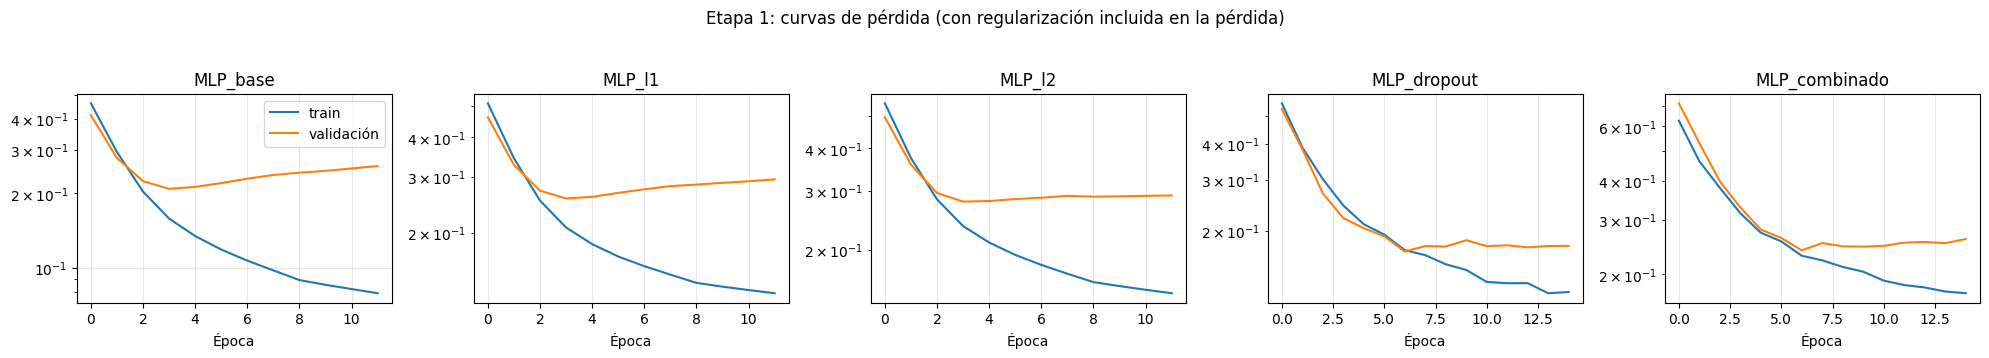

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.4))
for ax, (tipo, h) in zip(axes, hist_mlp_e1.items()):
    ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="validación")
    ax.set_title(f"MLP_{tipo}"); ax.set_yscale("log"); ax.grid(alpha=0.3); ax.set_xlabel("Época")
axes[0].legend(); fig.suptitle("Etapa 1: curvas de pérdida (con regularización incluida en la pérdida)", y=1.04)
plt.tight_layout(); plt.show()

## 4.2 SVC

In [17]:
tabla_svc_e1, cfg_svc_e1, sel_svc_e1 = seleccionar_sklearn(fabrica_svc, GRID_SVC, X_train, y1_train, X_val, y1_val, True, pesos_etapa1)
print("Mejor configuración:", cfg_svc_e1)
tabla_svc_e1.pivot(index="C", columns="gamma", values="puntaje_val").round(4)

Mejor configuración: {'C': 10, 'gamma': 'scale'}


gamma,0.1,scale
C,,
1,0.4871,0.5584
10,0.4868,0.5651
100,0.5213,0.5335


## 4.3 Random Forest

In [18]:
tabla_rf_e1, cfg_rf_e1, sel_rf_e1 = seleccionar_sklearn(fabrica_rf, GRID_RF, X_train, y1_train, X_val, y1_val, True, pesos_etapa1)
print("Mejor configuración:", cfg_rf_e1)
tabla_rf_e1.pivot(index="max_depth", columns="min_samples_leaf", values="puntaje_val").round(4)

Mejor configuración: {'max_depth': 12, 'min_samples_leaf': 1}


min_samples_leaf,1,20,5
max_depth,,,
12,0.8285,0.7461,0.7783
6,0.7686,0.7461,0.7502
None,0.8261,0.7483,0.7720


## 4.4 LightGBM

In [19]:
tabla_lgbm_e1, cfg_lgbm_e1, sel_lgbm_e1 = seleccionar_lgbm(X_train, y1_train, X_val, y1_val, True, pesos_etapa1)
print("Mejor configuración:", cfg_lgbm_e1)
tabla_lgbm_e1.pivot_table(index=["num_leaves", "min_child_samples"], columns="reg", values="puntaje_val").round(4)

Mejor configuración: {'num_leaves': 63, 'min_child_samples': 20, 'reg': 'sin reg.', 'n_estimators': 76}


reg                               L1      L2  sin reg.
num_leaves min_child_samples                          
15         20                 0.8047  0.7923    0.8150
           100                0.7791  0.7960    0.7958
63         20                 0.7996  0.8000    0.8189
           100                0.7856  0.7864    0.8157

## 4.5 Comparación en validación y reentrenamiento con todo el histórico

Se reentrena la mejor configuración de cada familia con entrenamiento + validación, y recién entonces se evalúa en el periodo de prueba.

In [20]:
cfg_e1 = {"MLP": cfg_mlp_e1, "SVC": cfg_svc_e1, "Random Forest": cfg_rf_e1, "LightGBM": cfg_lgbm_e1}
sel_e1 = {"MLP": sel_mlp_e1, "SVC": sel_svc_e1, "Random Forest": sel_rf_e1, "LightGBM": sel_lgbm_e1}
final_e1 = {}
filas = []
for fam in cfg_e1:
    t0 = time.time()
    final_e1[fam] = reentrenar(fam, cfg_e1[fam], X_hist, y1_hist, 2, pesos_clase(y1_hist, 2))
    r_te = metricas(y1_test, predecir(final_e1[fam], X_test), True)
    filas.append({"familia": fam, "config": str(cfg_e1[fam]),
                   "puntaje_val": puntaje(y1_val, predecir(sel_e1[fam], X_val), True),
                   **{f"{k}_test": v for k, v in r_te.items()}, "seg_reentreno": round(time.time() - t0, 1)})
comp_e1 = pd.DataFrame(filas).set_index("familia")
comp_e1.drop(columns="config").round(4)

,puntaje_val,accuracy_test,precision_test,recall_test,f1_test,falsas_alarmas_test,FAR_test,fallas_no_detectadas_test,seg_reentreno
familia,,,,,,,,,
MLP,0.7193,0.9171,0.5813,0.7642,0.6603,992,0.0649,425,3.2
SVC,0.5651,0.9258,0.6367,0.6887,0.6617,708,0.0463,561,3.3
Random Forest,0.8285,0.9526,0.8584,0.6593,0.7458,196,0.0128,614,10.4
LightGBM,0.8189,0.9529,0.8038,0.7320,0.7662,322,0.0211,483,0.6


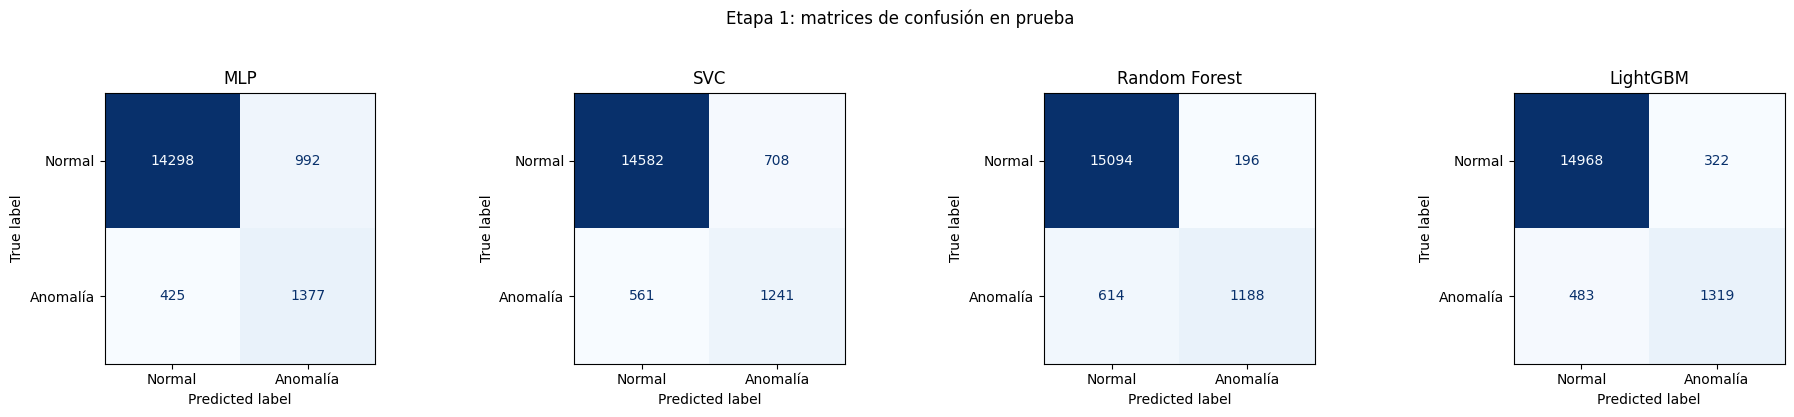

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, (fam, m) in zip(axes, final_e1.items()):
    ConfusionMatrixDisplay.from_predictions(y1_test, predecir(m, X_test), display_labels=["Normal", "Anomalía"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(fam)
fig.suptitle("Etapa 1: matrices de confusión en prueba", y=1.03); plt.tight_layout(); plt.show()

### Efecto de la regularización de la MLP en prueba

Para ver si la validación eligió bien, se reentrenan las cinco variantes MLP con todo el histórico y se evalúan en prueba.

In [22]:
filas = {}
for tipo in TIPOS_MLP:
    ep = int(tabla_mlp_e1.loc[tipo, "epocas_optimas"])
    m = reentrenar("MLP", {"tipo": tipo, "epocas": ep}, X_hist, y1_hist, 2, pesos_clase(y1_hist, 2))
    filas[f"MLP_{tipo}"] = {"puntaje_val": tabla_mlp_e1.loc[tipo, "puntaje_val"], **metricas(y1_test, predecir(m, X_test), True)}
pd.DataFrame(filas).T.round(4)

,puntaje_val,accuracy,precision,recall,f1,falsas_alarmas,FAR,fallas_no_detectadas
MLP_base,0.6195,0.9193,0.5926,0.7492,0.6618,928.0,0.0607,452.0
MLP_l1,0.6312,0.9193,0.5923,0.7514,0.6624,932.0,0.0610,448.0
MLP_l2,0.6349,0.9188,0.5904,0.7503,0.6608,938.0,0.0613,450.0
MLP_dropout,0.7193,0.9171,0.5813,0.7642,0.6603,992.0,0.0649,425.0
MLP_combinado,0.6644,0.9122,0.5601,0.7780,0.6513,1101.0,0.0720,400.0


# 5. Etapa 2: diagnóstico / aislamiento de la falla

El Modelo 2 solo recibe minutos con falla y decide cuál de las siete es. Las clases raras (intercambiador, rodamientos) ponen a prueba la regularización.

## 5.1 MLP

In [23]:
tabla_mlp_e2, cfg_mlp_e2, sel_mlp_e2, hist_mlp_e2 = seleccionar_mlp(X2_train, y2_train, X2_val, y2_val, N_FALLAS, pesos_etapa2)
print("Mejor variante:", cfg_mlp_e2)
tabla_mlp_e2.round(4)

Mejor variante: {'tipo': 'combinado', 'epocas': 31}


,epocas_optimas,val_loss,puntaje_val,seg
config,,,,
base,8,0.9920,0.5767,3.3
l1,6,1.0512,0.5701,2.9
l2,22,1.0429,0.6249,5.2
dropout,12,0.9048,0.6495,3.9
combinado,31,0.7023,0.7283,8.5


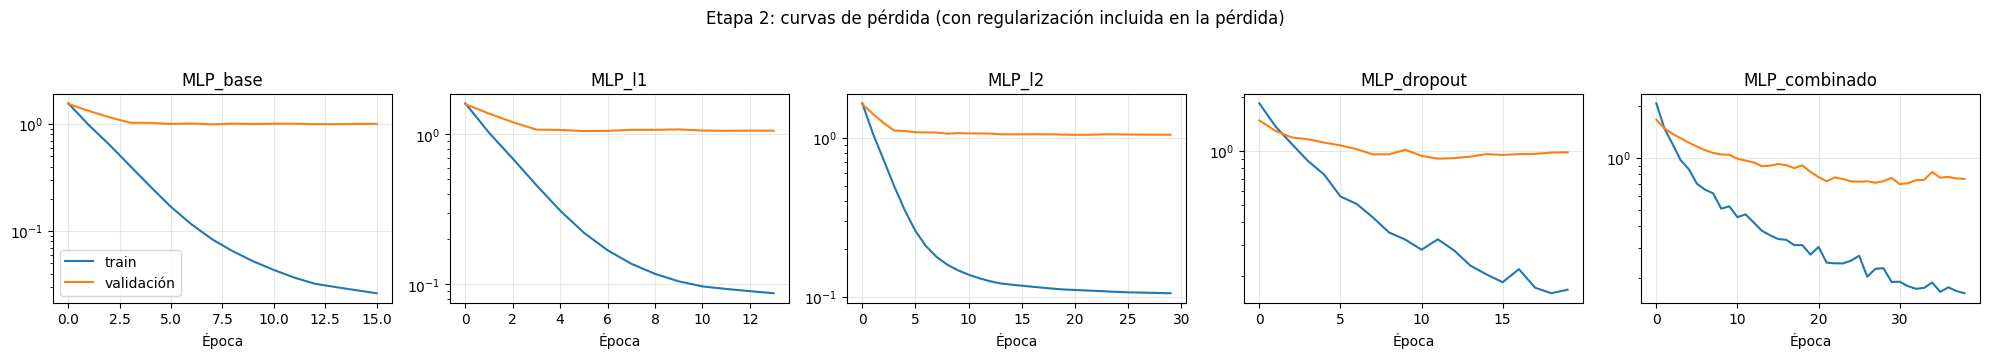

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.4))
for ax, (tipo, h) in zip(axes, hist_mlp_e2.items()):
    ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="validación")
    ax.set_title(f"MLP_{tipo}"); ax.set_yscale("log"); ax.grid(alpha=0.3); ax.set_xlabel("Época")
axes[0].legend(); fig.suptitle("Etapa 2: curvas de pérdida (con regularización incluida en la pérdida)", y=1.04)
plt.tight_layout(); plt.show()

## 5.2 SVC

In [25]:
tabla_svc_e2, cfg_svc_e2, sel_svc_e2 = seleccionar_sklearn(fabrica_svc, GRID_SVC, X2_train, y2_train, X2_val, y2_val, False, pesos_etapa2)
print("Mejor configuración:", cfg_svc_e2)
tabla_svc_e2.pivot(index="C", columns="gamma", values="puntaje_val").round(4)

Mejor configuración: {'C': 10, 'gamma': 'scale'}


gamma,0.1,scale
C,,
1,0.3975,0.7481
10,0.3933,0.7608
100,0.3933,0.7586


## 5.3 Random Forest

In [26]:
tabla_rf_e2, cfg_rf_e2, sel_rf_e2 = seleccionar_sklearn(fabrica_rf, GRID_RF, X2_train, y2_train, X2_val, y2_val, False, pesos_etapa2)
print("Mejor configuración:", cfg_rf_e2)
tabla_rf_e2.pivot(index="max_depth", columns="min_samples_leaf", values="puntaje_val").round(4)

Mejor configuración: {'max_depth': 12, 'min_samples_leaf': 5}


min_samples_leaf,1,20,5
max_depth,,,
12,0.7495,0.7469,0.7592
6,0.7528,0.7507,0.7281
None,0.7521,0.7469,0.7568


## 5.4 LightGBM

In [27]:
tabla_lgbm_e2, cfg_lgbm_e2, sel_lgbm_e2 = seleccionar_lgbm(X2_train, y2_train, X2_val, y2_val, False, pesos_etapa2)
print("Mejor configuración:", cfg_lgbm_e2)
tabla_lgbm_e2.pivot_table(index=["num_leaves", "min_child_samples"], columns="reg", values="puntaje_val").round(4)

Mejor configuración: {'num_leaves': 15, 'min_child_samples': 100, 'reg': 'L1', 'n_estimators': 62}


reg                               L1      L2  sin reg.
num_leaves min_child_samples                          
15         20                 0.6352  0.6464    0.6716
           100                0.7822  0.7692    0.7741
63         20                 0.6347  0.6486    0.6800
           100                0.7822  0.7692    0.7772

## 5.5 Comparación en validación y reentrenamiento con todo el histórico

Se reentrena la mejor configuración de cada familia con entrenamiento + validación, y recién entonces se evalúa en el periodo de prueba.

In [28]:
cfg_e2 = {"MLP": cfg_mlp_e2, "SVC": cfg_svc_e2, "Random Forest": cfg_rf_e2, "LightGBM": cfg_lgbm_e2}
sel_e2 = {"MLP": sel_mlp_e2, "SVC": sel_svc_e2, "Random Forest": sel_rf_e2, "LightGBM": sel_lgbm_e2}
final_e2 = {}
filas = []
for fam in cfg_e2:
    t0 = time.time()
    final_e2[fam] = reentrenar(fam, cfg_e2[fam], X2_hist, y2_hist, N_FALLAS, pesos_clase(y2_hist, N_FALLAS))
    r_te = metricas(y2_test, predecir(final_e2[fam], X2_test), False)
    filas.append({"familia": fam, "config": str(cfg_e2[fam]),
                   "puntaje_val": puntaje(y2_val, predecir(sel_e2[fam], X2_val), False),
                   **{f"{k}_test": v for k, v in r_te.items()}, "seg_reentreno": round(time.time() - t0, 1)})
comp_e2 = pd.DataFrame(filas).set_index("familia")
comp_e2.drop(columns="config").round(4)

,puntaje_val,accuracy_test,precision_test,recall_test,f1_test,seg_reentreno
familia,,,,,,
MLP,0.7283,0.8036,0.7826,0.9253,0.8058,5.8
SVC,0.7608,0.8152,0.7672,0.6500,0.6830,0.1
Random Forest,0.7592,0.8607,0.8288,0.6572,0.7204,2.1
LightGBM,0.7822,0.9356,0.9459,0.9305,0.9360,0.2


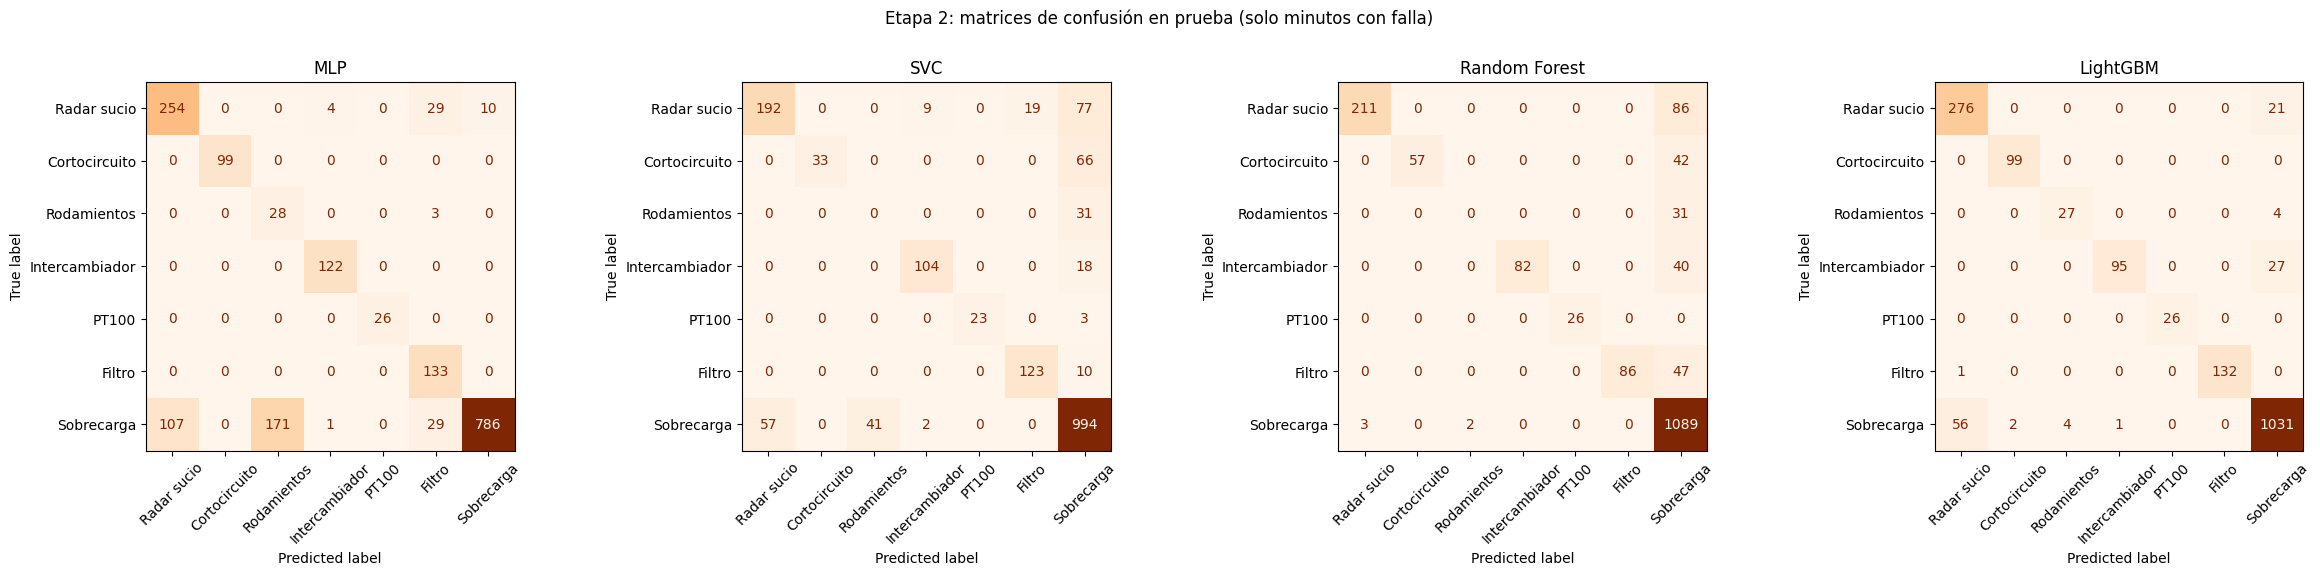

In [29]:
nombres_cortos = [etiquetas_cortas[c] for c in le_falla.classes_]
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))
for ax, (fam, m) in zip(axes, final_e2.items()):
    ConfusionMatrixDisplay.from_predictions(y2_test, predecir(m, X2_test), labels=range(N_FALLAS),
                                            display_labels=nombres_cortos, cmap="Oranges", colorbar=False, ax=ax)
    ax.set_title(fam); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Etapa 2: matrices de confusión en prueba (solo minutos con falla)", y=1.02); plt.tight_layout(); plt.show()

### Efecto de la regularización de la MLP en prueba

Para ver si la validación eligió bien, se reentrenan las cinco variantes MLP con todo el histórico y se evalúan en prueba.

In [30]:
filas = {}
for tipo in TIPOS_MLP:
    ep = int(tabla_mlp_e2.loc[tipo, "epocas_optimas"])
    m = reentrenar("MLP", {"tipo": tipo, "epocas": ep}, X2_hist, y2_hist, N_FALLAS, pesos_clase(y2_hist, N_FALLAS))
    filas[f"MLP_{tipo}"] = {"puntaje_val": tabla_mlp_e2.loc[tipo, "puntaje_val"], **metricas(y2_test, predecir(m, X2_test), False)}
pd.DataFrame(filas).T.round(4)

,puntaje_val,accuracy,precision,recall,f1
MLP_base,0.5767,0.7586,0.6289,0.6301,0.6079
MLP_l1,0.5701,0.7331,0.6370,0.6140,0.5906
MLP_l2,0.6249,0.8069,0.7406,0.6769,0.6547
MLP_dropout,0.6495,0.7814,0.7340,0.8525,0.7616
MLP_combinado,0.7283,0.8036,0.7826,0.9253,0.8058


# 6. Sistema jerárquico completo

## 6.1 Inferencia en cascada

In [31]:
class DiagnosticoJerarquico:
    def __init__(self, detector, diagnosticador):
        self.detector, self.diagnosticador = detector, diagnosticador

    def predecir_etiqueta(self, X):
        anomalia = predecir(self.detector, X)
        salida = np.array(["Normal"] * len(X), dtype=object)
        idx = np.where(anomalia == 1)[0]
        if len(idx):
            salida[idx] = le_falla.inverse_transform(predecir(self.diagnosticador, X[idx]))
        return salida

    def mensaje(self, X):
        return ["[OK: Continuar Monitoreo]" if e == "Normal" else f"[ALERTA] Diagnóstico: {e}"
                for e in self.predecir_etiqueta(X)]

## 6.2 Comparación de sistemas

Se arman cinco sistemas: uno por familia (la misma familia en ambas etapas) y un **híbrido** que combina la mejor familia de cada etapa según validación.

* **Validación** se evalúa con los modelos entrenados solo con el conjunto de entrenamiento.
* **Prueba** se evalúa con los modelos reentrenados con todo el histórico.

El **mejor sistema** se elige por F1-macro en **validación**, nunca mirando la prueba.

In [32]:
y_val_real, y_test_real = df_val[TARGET].values, df_test[TARGET].values
FAMILIAS = ["MLP", "SVC", "Random Forest", "LightGBM"]
mejor_fam_e1 = max(FAMILIAS, key=lambda f: comp_e1.loc[f, "puntaje_val"])
mejor_fam_e2 = max(FAMILIAS, key=lambda f: comp_e2.loc[f, "puntaje_val"])

combinaciones = {f"{f} -> {f}": (f, f) for f in FAMILIAS}
combinaciones[f"Híbrido: {mejor_fam_e1} -> {mejor_fam_e2}"] = (mejor_fam_e1, mejor_fam_e2)

def f1_presentes(y, pred):
    return f1_score(y, pred, labels=np.unique(y), average="macro", zero_division=0)

filas, sistemas = [], {}
for nombre, (f1_, f2_) in combinaciones.items():
    s_val = DiagnosticoJerarquico(sel_e1[f1_], sel_e2[f2_])
    sistemas[nombre] = DiagnosticoJerarquico(final_e1[f1_], final_e2[f2_])
    p_val, p_te = s_val.predecir_etiqueta(X_val), sistemas[nombre].predecir_etiqueta(X_test)
    fa = ((y_test_real == "Normal") & (p_te != "Normal")).sum()
    om = ((y_test_real != "Normal") & (p_te == "Normal")).sum()
    filas.append({"sistema": nombre, "f1_macro_val": f1_presentes(y_val_real, p_val),
                  "f1_macro_test": f1_presentes(y_test_real, p_te), "accuracy_test": accuracy_score(y_test_real, p_te),
                  "falsas_alarmas_test": int(fa), "FAR_test": fa / (y_test_real == "Normal").sum(),
                  "fallas_omitidas_test": int(om)})
comp_sistemas = pd.DataFrame(filas).set_index("sistema").sort_values("f1_macro_val", ascending=False)
MEJOR_SISTEMA = comp_sistemas.index[0]
print("Mejor sistema según validación:", MEJOR_SISTEMA)
comp_sistemas.round(4)

Mejor sistema según validación: LightGBM -> LightGBM


,f1_macro_val,f1_macro_test,accuracy_test,falsas_alarmas_test,FAR_test,fallas_omitidas_test
sistema,,,,,,
LightGBM -> LightGBM,0.6034,0.5724,0.9491,322,0.0211,483
Híbrido: Random Forest -> LightGBM,0.5860,0.4988,0.9487,196,0.0128,614
Random Forest -> Random Forest,0.5786,0.4236,0.9485,196,0.0128,614
MLP -> MLP,0.5154,0.5536,0.9022,992,0.0649,425
SVC -> SVC,0.4830,0.4677,0.9138,708,0.0463,561


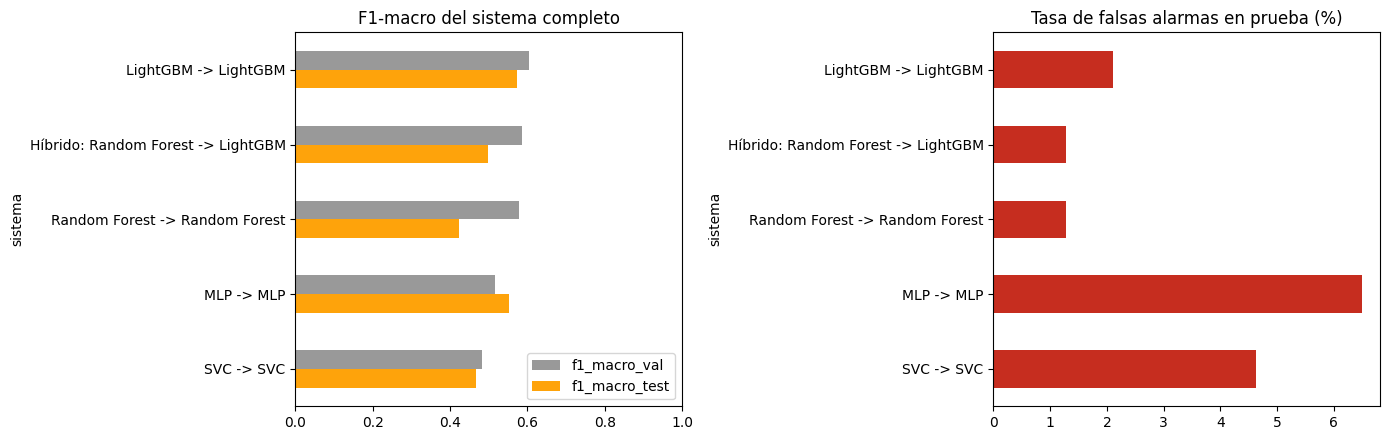

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
comp_sistemas[["f1_macro_val", "f1_macro_test"]].plot(kind="barh", ax=ax[0], color=["#999", "#FEA30B"])
ax[0].set_title("F1-macro del sistema completo"); ax[0].invert_yaxis(); ax[0].set_xlim(0, 1)
(comp_sistemas["FAR_test"] * 100).plot(kind="barh", ax=ax[1], color="#C62D1F")
ax[1].set_title("Tasa de falsas alarmas en prueba (%)"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 6.3 F1 por tipo de falla

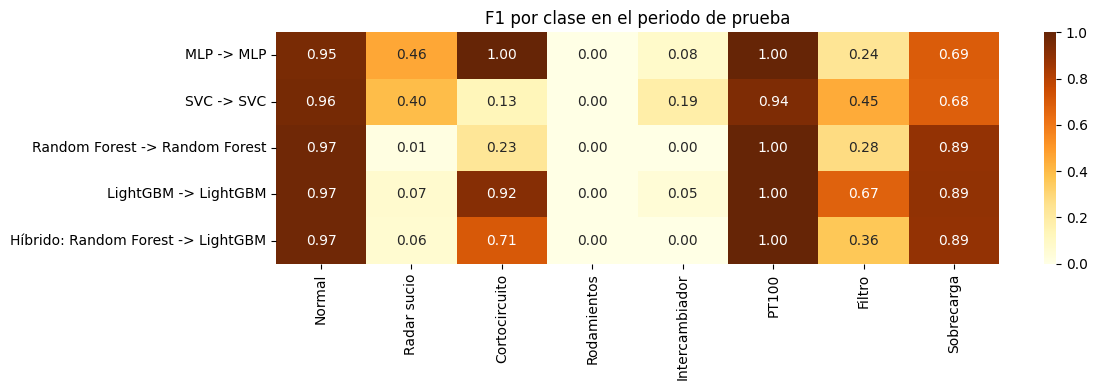

In [34]:
orden = ["Normal"] + list(le_falla.classes_)
f1_clase = pd.DataFrame({n: f1_score(y_test_real, s.predecir_etiqueta(X_test), labels=orden, average=None, zero_division=0)
                         for n, s in sistemas.items()}, index=[etiquetas_cortas[c] for c in orden]).T
plt.figure(figsize=(12, 4))
sns.heatmap(f1_clase, annot=True, fmt=".2f", cmap="YlOrBr", vmin=0, vmax=1)
plt.title("F1 por clase en el periodo de prueba"); plt.tight_layout(); plt.show()

## 6.4 Robustez frente a ruido de medición

Se agrega ruido gaussiano a los sensores del conjunto de prueba (las variables de contexto no se alteran).

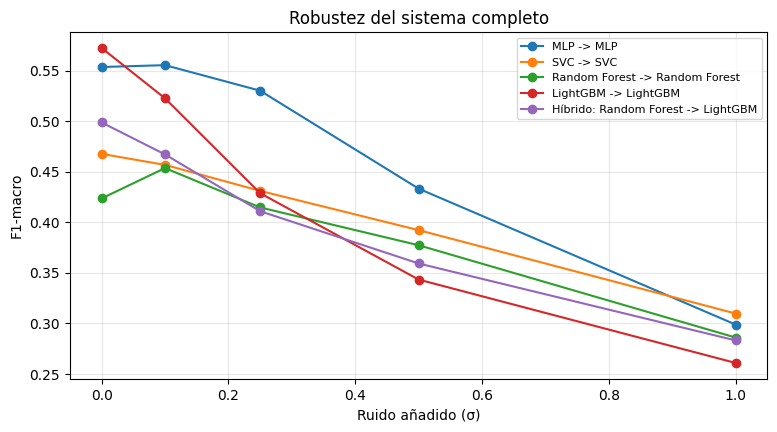

sistema,Híbrido: Random Forest -> LightGBM,LightGBM -> LightGBM,MLP -> MLP,Random Forest -> Random Forest,SVC -> SVC
ruido_sigma,,,,,
0.00,0.4988,0.5724,0.5536,0.4236,0.4677
0.10,0.4671,0.5226,0.5554,0.4536,0.4568
0.25,0.4110,0.4288,0.5302,0.4147,0.4311
0.50,0.3593,0.3434,0.4333,0.3773,0.3923
1.00,0.2832,0.2609,0.2988,0.2860,0.3098


In [35]:
niveles_ruido = [0.0, 0.1, 0.25, 0.5, 1.0]
rng = np.random.default_rng(SEED)
ruido_base = rng.standard_normal(X_test.shape).astype("float32")
ruido_base[:, [FEATURES.index(c) for c in CONTEXTO]] = 0

filas = []
for nivel in niveles_ruido:
    Xr = X_test + nivel * ruido_base
    for nombre, s in sistemas.items():
        filas.append({"ruido_sigma": nivel, "sistema": nombre, "f1_macro": f1_presentes(y_test_real, s.predecir_etiqueta(Xr))})
robustez = pd.DataFrame(filas)
plt.figure(figsize=(9, 4.5))
for nombre, g in robustez.groupby("sistema", sort=False):
    plt.plot(g["ruido_sigma"], g["f1_macro"], marker="o", label=nombre)
plt.xlabel("Ruido añadido (σ)"); plt.ylabel("F1-macro"); plt.title("Robustez del sistema completo")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.show()
robustez.pivot(index="ruido_sigma", columns="sistema", values="f1_macro").round(4)

## 6.5 ¿Las "falsas alarmas" anticipan fallas reales?

Las fallas de este dataset se desarrollan por degradación progresiva y la etiqueta cambia solo al cruzar un umbral. Se mide cuánto tiempo falta, desde cada falsa alarma, hasta el inicio de la siguiente falla real.

In [36]:
etq = df_completo[TARGET]
inicio_fallas = df_completo.loc[(etq != "Normal") & (etq.shift() != etq), "timestamp"].sort_values().values

def horas_hasta_proxima_falla(tiempos):
    idx = np.searchsorted(inicio_fallas, tiempos.values)
    ok = idx < len(inicio_fallas)
    h = np.full(len(tiempos), np.inf)
    h[ok] = (inicio_fallas[idx[ok]] - tiempos.values[ok]) / np.timedelta64(1, "h")
    return h

tramos, nombres = [0, 24, 72, 168, np.inf], ["menos de 1 día", "1 a 3 días", "3 a 7 días", "más de 7 días"]
filas = {}
for nombre, s in sistemas.items():
    pred = s.predecir_etiqueta(X_test)
    fp = (y_test_real == "Normal") & (pred != "Normal")
    h = horas_hasta_proxima_falla(df_test.loc[fp, "timestamp"])
    filas[nombre] = pd.Series(pd.cut(h, tramos, labels=nombres)).value_counts(normalize=True).reindex(nombres).mul(100).round(1)
anticipacion = pd.DataFrame(filas).T
anticipacion.columns.name = "% de falsas alarmas según tiempo hasta la próxima falla"
anticipacion

% de falsas alarmas según tiempo hasta la próxima falla,menos de 1 día,1 a 3 días,3 a 7 días,más de 7 días
MLP -> MLP,58.1,30.1,2.3,9.5
SVC -> SVC,49.2,41.8,2.7,6.4
Random Forest -> Random Forest,68.9,22.4,7.1,1.5
LightGBM -> LightGBM,80.4,14.0,4.7,0.9
Híbrido: Random Forest -> LightGBM,68.9,22.4,7.1,1.5


## 6.6 ¿Qué sensores usan los modelos de árboles?

LightGBM y Random Forest indican cuánto contribuye cada variable a sus decisiones. Es una forma directa de verificar que el modelo usa la física correcta y no atajos.

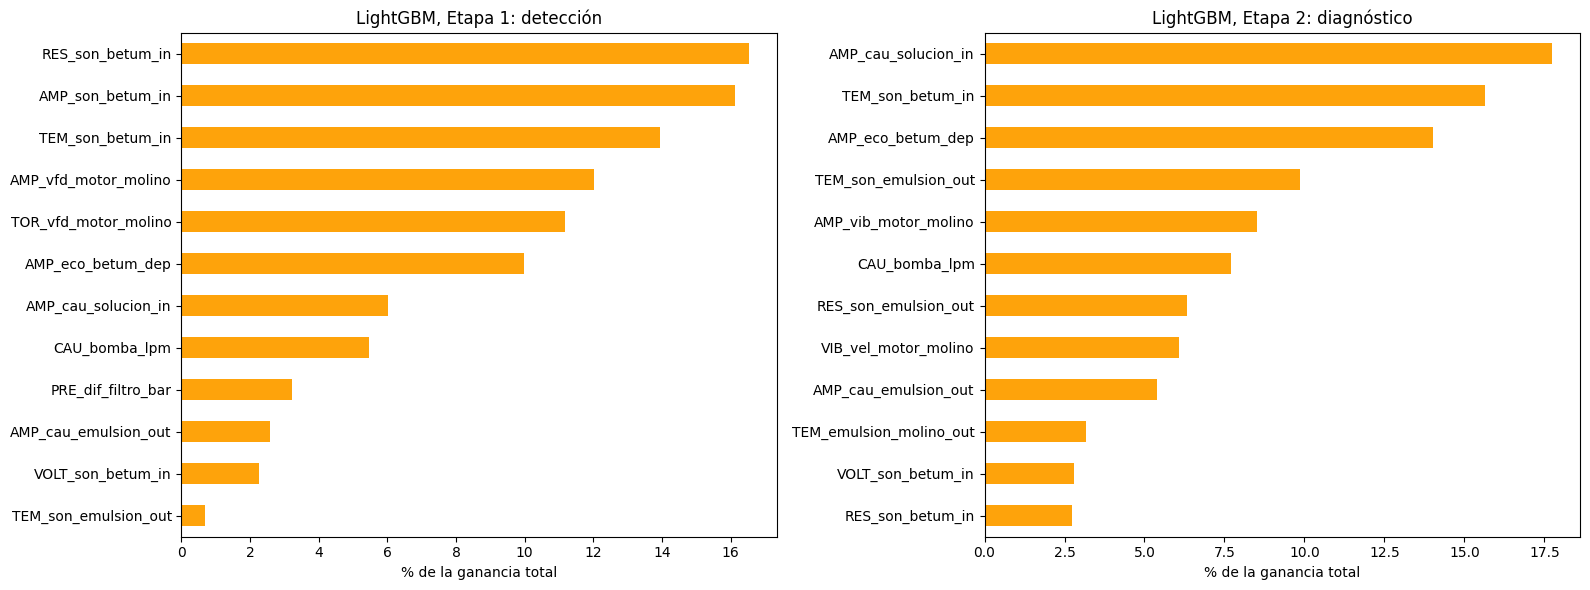

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (titulo, m) in zip(axes, [("Etapa 1: detección", final_e1["LightGBM"]), ("Etapa 2: diagnóstico", final_e2["LightGBM"])]):
    imp = pd.Series(m.booster_.feature_importance("gain"), index=FEATURES).sort_values().tail(12)
    (imp / imp.sum() * 100).plot(kind="barh", ax=ax, color="#FEA30B")
    ax.set_title(f"LightGBM, {titulo}"); ax.set_xlabel("% de la ganancia total")
plt.tight_layout(); plt.show()

## 6.7 Reporte del mejor sistema

Sistema: LightGBM -> LightGBM 

                                     precision    recall  f1-score   support

                             Normal     0.9687    0.9789    0.9738     15290
      Advertencia_Radar_Sucio_Betun     0.1081    0.0539    0.0719       297
Cortocircuito_Transmisor_Caudal_Sol     0.8534    1.0000    0.9209        99
        Desgaste_Rodamientos_Molino     0.0000    0.0000    0.0000        31
       Ensuciamiento_Intercambiador     1.0000    0.0246    0.0480       122
        Falla_Electrica_PT100_Betun     1.0000    1.0000    1.0000        26
                   Filtro_Obstruido     0.5567    0.8496    0.6726       133
  Sobrecarga_Motor_Por_Asfalto_Frio     0.8738    0.9113    0.8922      1094

                           accuracy                         0.9491     17092
                          macro avg     0.6701    0.6023    0.5724     17092
                       weighted avg     0.9423    0.9491    0.9419     17092



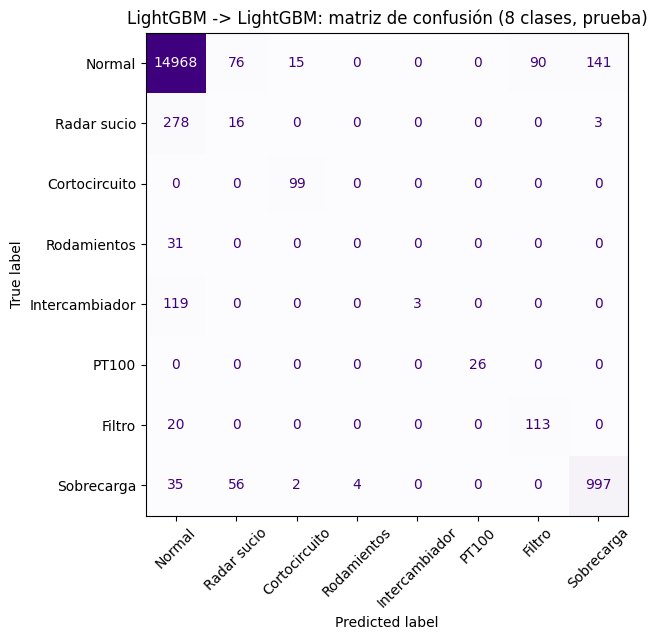

In [38]:
sistema_final = sistemas[MEJOR_SISTEMA]
pred_final = sistema_final.predecir_etiqueta(X_test)
print("Sistema:", MEJOR_SISTEMA, "\n")
print(classification_report(y_test_real, pred_final, labels=orden, digits=4, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6.5))
ConfusionMatrixDisplay.from_predictions(y_test_real, pred_final, labels=orden,
                                        display_labels=[etiquetas_cortas[c] for c in orden],
                                        cmap="Purples", colorbar=False, ax=ax)
ax.set_title(f"{MEJOR_SISTEMA}: matriz de confusión (8 clases, prueba)"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 7. Conclusiones

*(Valores de la ejecución de referencia; pueden variar levemente entre corridas, sobre todo en las MLP.)*

## 7.1 Mejor modelo: LightGBM en ambas etapas

| Sistema | F1-macro validación | F1-macro prueba | Falsas alarmas (prueba) |
|---|---|---|---|
| **LightGBM → LightGBM** | **0,60** | **0,57** | 2,1 % |
| Híbrido Random Forest → LightGBM | 0,59 | 0,50 | 1,3 % |
| Random Forest → Random Forest | 0,58 | 0,42 | 1,3 % |
| MLP → MLP | 0,52 | 0,55 | 6,5 % |
| SVC → SVC | 0,48 | 0,47 | 4,6 % |

LightGBM fue el mejor sistema en validación, que es el criterio de selección, y también en prueba. Es el que se exporta.

* **Detección (Etapa 1):** LightGBM (F1 0,77) y Random Forest (0,75) superan a la MLP y al SVC (0,66). Random Forest tiene la menor tasa de falsas alarmas (1,3 %), pero deja pasar más fallas.
* **Diagnóstico (Etapa 2):** LightGBM es claramente superior (F1 0,94 en prueba), seguido por la MLP combinada (0,81). El SVC queda último (0,68).
* **Por falla**, el sistema LightGBM identifica muy bien la Pt100 (F1 1,00), el cortocircuito (0,92), la sobrecarga (0,89) y el filtro (0,67).

## 7.2 Dónde falla el sistema

El radar sucio (F1 0,07), el intercambiador (0,05) y los rodamientos (0,00) casi no se detectan. Como la Etapa 2 diagnostica bien cuando recibe la falla, el problema está en la **detección**:

* **Intercambiador y rodamientos:** en el entrenamiento hubo 11 y 0 minutos respectivamente (el único episodio de rodamientos del histórico cayó en validación). Ningún modelo puede aprender bien una falla que casi no vio.
* **Radar sucio:** la costra se forma de a poco y el eco cruza el umbral de forma gradual, con mucha superposición con la operación normal.

## 7.3 Efecto de la regularización

La regularización mostró su valor en cada familia, y la **validación cronológica** permitió elegirla correctamente (en la versión anterior, con validación al azar, todos los modelos marcaban 1,0 y se elegía la MLP sin regularizar):

* **MLP, Etapa 2:** la variante combinada (L2 + BatchNorm + Dropout) logró F1 0,81 en prueba, contra 0,61 de la red sin regularizar. La validación la eligió correctamente.
* **LightGBM, Etapa 2:** exigir al menos 100 muestras por hoja (`min_child_samples`) subió el F1 de validación de ~0,65 a ~0,78. Es la regularización más efectiva para fallas con pocos ejemplos.
* **LightGBM, early stopping:** cortó el entrenamiento en 62 a 76 árboles de un máximo de 1.000.
* **Random Forest:** limitar la profundidad a 12 niveles fue igual o mejor que árboles sin límite.
* **SVC:** `gamma = "scale"` (frontera más suave) superó claramente a `gamma = 0,1`.

## 7.4 Robustez frente a ruido

Con ruido moderado (0,25–0,5 σ), la **MLP se degrada más lento** que los modelos de árboles: a 0,5 σ mantiene F1 0,43, contra 0,34 de LightGBM. Los árboles toman decisiones con umbrales fijos y el ruido los cruza fácilmente; la red tiene fronteras más suaves. Si los sensores de la planta real resultan ruidosos, conviene volver a comparar con datos reales.

## 7.5 Las "falsas alarmas" son en su mayoría avisos anticipados

En el sistema LightGBM, el **80 % de las falsas alarmas ocurre menos de un día antes de una falla real**, y el 94 % dentro de los tres días previos. Es decir, el modelo detecta la degradación antes de que la etiqueta la reconozca como falla. En operación, estas alertas son útiles: indican que un equipo está próximo a fallar.

## 7.6 Recomendaciones

1. **Usar LightGBM** como modelo de identificación de fallas en el dashboard.
2. **Complementar con reglas fijas** para fallas de instrumento (lazo sobre 21 mA, Pt100 sin alimentación) y con el **autoencoder** para fallas raras o nuevas, que son justo las que este modelo no alcanza a aprender.
3. **Agregar variables de tendencia** (promedio y pendiente de los últimos 30–60 minutos) para mejorar la detección de fallas graduales como el radar sucio.
4. **Reentrenar periódicamente** a medida que se acumulen episodios de las fallas raras, aprovechando las etiquetas que el operador registra en el dashboard.


# 8. Descarga del mejor modelo

Se empaqueta el **mejor sistema según validación** en un `.zip`:

* `config_modelo.joblib`: escalador, lista ordenada de variables, decodificador de fallas, familia de cada etapa, alcance y variables de contexto. Si una etapa es de scikit-learn o LightGBM, el modelo va dentro de este archivo.
* `etapa1.keras` y/o `etapa2.keras`: solo si alguna etapa es una MLP.

Para cargarlo en otro entorno se necesitan las mismas versiones de scikit-learn, LightGBM y TensorFlow (quedan registradas dentro del paquete).

In [39]:
fam1, fam2 = combinaciones[MEJOR_SISTEMA]
config = {
    "sistema": MEJOR_SISTEMA,
    "familias": {"etapa1": fam1, "etapa2": fam2},
    "configuraciones": {"etapa1": cfg_e1[fam1], "etapa2": cfg_e2[fam2]},
    "scaler": scaler, "features": FEATURES, "label_encoder_fallas": le_falla,
    "alcance": "Solo minutos con el molino en marcha: ESTADO_operacion en {Produccion, Limpieza}",
    "contexto": {"es_plastomerico": "1 si TIPO_asfalto == 'Plastomerico'",
                 "en_limpieza": "1 si ESTADO_operacion == 'Limpieza'"},
    "metricas_test": comp_sistemas.loc[MEJOR_SISTEMA].to_dict(),
    "versiones": {"sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "tensorflow": tf.__version__},
}
archivos = ["config_modelo.joblib"]
for etapa, fam, modelo in [("etapa1", fam1, final_e1[fam1]), ("etapa2", fam2, final_e2[fam2])]:
    if fam == "MLP":
        modelo.save(f"{etapa}.keras"); archivos.append(f"{etapa}.keras")
        config[f"modelo_{etapa}"] = f"{etapa}.keras"
    else:
        config[f"modelo_{etapa}"] = modelo
joblib.dump(config, "config_modelo.joblib")

ZIP = "mejor_modelo_molino_QLA.zip"
with zipfile.ZipFile(ZIP, "w") as z:
    for a in archivos:
        z.write(a)
print(f"Sistema exportado: {MEJOR_SISTEMA} -> {ZIP} ({', '.join(archivos)})")

try:
    from google.colab import files
    files.download(ZIP)
except ImportError:
    print("No se está ejecutando en Colab: el .zip quedó en la carpeta actual.")

Sistema exportado: LightGBM -> LightGBM -> mejor_modelo_molino_QLA.zip (config_modelo.joblib)
No se está ejecutando en Colab: el .zip quedó en la carpeta actual.


## 8.1 Cómo usar el modelo descargado

Descomprime el `.zip` en la carpeta de trabajo y usa estas funciones:

In [40]:
from tensorflow.keras.models import load_model

def cargar_sistema(ruta_config="config_modelo.joblib"):
    cfg = joblib.load(ruta_config)
    for etapa in ("etapa1", "etapa2"):
        if isinstance(cfg[f"modelo_{etapa}"], str):
            cfg[f"modelo_{etapa}"] = load_model(cfg[f"modelo_{etapa}"])
    return cfg

def _predecir(modelo, X):
    if isinstance(modelo, keras.Model):
        p = modelo.predict(X, verbose=0)
        return (p.ravel() >= 0.5).astype(int) if p.shape[1] == 1 else p.argmax(axis=1)
    return modelo.predict(X)

def diagnosticar(cfg, df_lecturas):
    d = df_lecturas.copy()
    d["es_plastomerico"] = (d["TIPO_asfalto"] == "Plastomerico").astype(int)
    d["en_limpieza"] = (d["ESTADO_operacion"] == "Limpieza").astype(int)
    salida = np.array(["[Molino detenido: fuera del alcance del modelo]"] * len(d), dtype=object)
    marcha = d["ESTADO_operacion"].isin(["Produccion", "Limpieza"]).values
    if marcha.any():
        X = cfg["scaler"].transform(d.loc[marcha, cfg["features"]]).astype("float32")
        anomalia = _predecir(cfg["modelo_etapa1"], X)
        res = np.array(["[OK: Continuar Monitoreo]"] * len(X), dtype=object)
        idx = np.where(anomalia == 1)[0]
        if len(idx):
            fallas = cfg["label_encoder_fallas"].inverse_transform(_predecir(cfg["modelo_etapa2"], X[idx]))
            res[idx] = [f"[ALERTA] Diagnóstico: {f}" for f in fallas]
        salida[marcha] = res
    return list(salida)

sistema_cargado = cargar_sistema()
ejemplo = df_completo[df_completo["ESTADO_operacion"] != "Detenida"].groupby(TARGET).sample(1, random_state=3)
pd.DataFrame({"estado_operacion": ejemplo["ESTADO_operacion"].values, "estado_real": ejemplo[TARGET].values,
              "salida_del_modelo": diagnosticar(sistema_cargado, ejemplo)})

,estado_operacion,estado_real,salida_del_modelo
0,Espera,Advertencia_Radar_Sucio_Betun,[Molino detenido: fuera del alcance del modelo]
1,Espera,Cortocircuito_Transmisor_Caudal_Sol,[Molino detenido: fuera del alcance del modelo]
2,Limpieza,Desgaste_Rodamientos_Molino,[OK: Continuar Monitoreo]
3,Produccion,Ensuciamiento_Intercambiador,[ALERTA] Diagnóstico: Ensuciamiento_Intercambi...
4,Preparacion,Falla_Electrica_PT100_Betun,[Molino detenido: fuera del alcance del modelo]
5,Produccion,Filtro_Obstruido,[ALERTA] Diagnóstico: Filtro_Obstruido
6,Espera,Normal,[Molino detenido: fuera del alcance del modelo]
7,Produccion,Sobrecarga_Motor_Por_Asfalto_Frio,[ALERTA] Diagnóstico: Sobrecarga_Motor_Por_Asf...
